# 🚀 Dự đoán thời gian giao hàng (Bài toán hồi quy)

## 🎯 Mô tả bài toán

Trong đề tài này, chúng tôi xây dựng một mô hình học máy nhằm dự đoán thời gian giao hàng (Delivery Duration) của các đơn hàng dựa trên nhiều yếu tố khác nhau như khoảng cách, tình trạng giao thông, thông tin đơn hàng và đặc điểm của tài xế.

Thời gian giao hàng là một yếu tố quan trọng trong các hệ thống giao đồ ăn, ảnh hưởng trực tiếp đến trải nghiệm khách hàng cũng như hiệu quả vận hành của doanh nghiệp.

---

## 📌 Mục tiêu

* Dự đoán giá trị **Delivery_Duration_Minutes** cho mỗi đơn hàng
* Xác định các yếu tố ảnh hưởng đến thời gian giao hàng
* Xây dựng và so sánh các mô hình hồi quy khác nhau
* Đánh giá mô hình bằng các chỉ số như **Mean Squared Error (MSE)**

---

## 🧠 Loại bài toán

* Đây là bài toán **Học có giám sát (Supervised Learning)**
* Thuộc dạng **Hồi quy (Regression)** do biến mục tiêu là giá trị liên tục

---

## 📊 Kết quả kỳ vọng

* Xây dựng được mô hình dự đoán thời gian giao hàng với độ chính xác cao
* Phân tích được mức độ ảnh hưởng của các yếu tố như khoảng cách, giao thông, phương tiện giao hàng
* So sánh hiệu năng giữa các mô hình khác nhau


## 📦 Import Libraries

- `numpy`: Thư viện hỗ trợ tính toán số học, xử lý mảng và ma trận  
- `pandas`: Dùng để xử lý và phân tích dữ liệu dạng bảng (DataFrame)  

- `matplotlib.pyplot`: Thư viện vẽ biểu đồ cơ bản  
- `seaborn`: Thư viện trực quan hóa dữ liệu nâng cao, giúp biểu đồ trực quan hơn  

- `train_test_split`: Dùng để chia dữ liệu thành tập train và test  
- `mean_squared_error`, `mean_absolute_error`: Các chỉ số đánh giá mô hình hồi quy  

- `LinearRegression`: Mô hình hồi quy tuyến tính  
- `RandomForestRegressor`: Mô hình ensemble dựa trên nhiều cây quyết định  

- `pd.set_option("display.max_columns", None)`: Hiển thị đầy đủ các cột trong DataFrame  

- `warnings.filterwarnings("ignore")`: Tắt các cảnh báo không cần thiết để output gọn gàng hơn  

In [51]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# display settings
pd.set_option("display.max_columns", None)

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 📥 Load Dataset

- Sử dụng `pd.read_csv()` để đọc dữ liệu từ file CSV và lưu vào DataFrame `df`  
- Dataset chứa thông tin về các đơn hàng giao đồ ăn  

- `df.head()` được sử dụng để hiển thị 5 dòng đầu tiên của dữ liệu  
→ Giúp kiểm tra nhanh cấu trúc, tên cột và định dạng dữ liệu  

In [52]:
# Load dataset
df = pd.read_csv("/Users/huynh/codes/project_hocmay/data/talabat_enhanced_orders.csv")

# Show first 5 rows
df.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,Alexandria,Wallet,Delivered,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,Zagazig,Credit Card,Delivered,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,Assiut,Cash,In Transit,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,Mansoura,Cash,Delivered,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,Mansoura,Wallet,Delivered,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


## 📊 Data Overview

- `df.shape`: Cho biết số lượng dòng và cột của dataset  
- `df.info()`: Hiển thị thông tin tổng quan về dữ liệu như kiểu dữ liệu và số lượng giá trị không bị thiếu  
- `df.describe()`: Thống kê các đặc trưng số như trung bình, độ lệch chuẩn, giá trị lớn nhất/nhỏ nhất  

- `df.isnull().sum()`: Kiểm tra số lượng giá trị bị thiếu trong từng cột  
- `df.duplicated().sum()`: Kiểm tra số lượng bản ghi bị trùng lặp  

In [53]:
# shape of dataset
df.shape

(100000, 23)

In [54]:
# dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100000 non-null  int64  
 1   User_ID                    100000 non-null  str    
 2   Restaurant_ID              100000 non-null  int64  
 3   Driver_ID                  100000 non-null  int64  
 4   Item_Name                  100000 non-null  str    
 5   Quantity                   100000 non-null  int64  
 6   Total_Price                100000 non-null  float64
 7   Order_Time                 100000 non-null  str    
 8   Delivery_Time              100000 non-null  str    
 9   Delivery_Duration_Minutes  100000 non-null  int64  
 10  City                       100000 non-null  str    
 11  Payment_Method             100000 non-null  str    
 12  Order_Status               100000 non-null  str    
 13  Driver_Vehicle             100000 non-nul

In [55]:
# statistical summary
df.describe()

,Order_ID,Restaurant_ID,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,499.832850,250.791800,2.991110,268.925734,37.520110,30.119015,31.063065,30.119060,31.062971,30.119075,31.062993,2.165303
std,28867.657797,288.255257,144.289418,1.410132,170.490396,10.060876,1.271638,0.487754,1.271674,0.487811,1.271699,0.487826,1.038473
min,1.000000,1.000000,1.000000,1.000000,30.000000,15.000000,27.160900,29.898701,27.160900,29.898706,27.160901,29.898703,0.008839
25%,25000.750000,250.000000,126.000000,2.000000,129.430000,30.000000,30.023110,31.008774,30.023370,31.008460,30.023295,31.008410,1.355602
50%,50000.500000,499.000000,251.000000,3.000000,233.200000,38.000000,30.587306,31.209099,30.587054,31.208817,30.587085,31.209075,2.122694
75%,75000.250000,750.000000,376.000000,4.000000,381.510000,45.000000,31.026912,31.371676,31.027112,31.371856,31.027241,31.371508,2.924525
max,100000.000000,1000.000000,500.000000,5.000000,750.000000,60.000000,31.220099,31.521997,31.220096,31.521995,31.220099,31.521999,5.597928


In [56]:
# check missing values
df.isnull().sum()

Order_ID                     0
User_ID                      0
Restaurant_ID                0
Driver_ID                    0
Item_Name                    0
Quantity                     0
Total_Price                  0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Order_Status                 0
Driver_Vehicle               0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Driver_Lat                   0
Driver_Lon                   0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64

In [57]:
# check duplicates
df.duplicated().sum()

np.int64(0)

In [58]:
df.columns

Index(['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name',
       'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time',
       'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status',
       'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
       'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km',
       'Traffic_Level', 'Driver_Availability'],
      dtype='str')

In [59]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['User_ID', 'Item_Name', 'Order_Time', 'Delivery_Time', 'City',
       'Payment_Method', 'Order_Status', 'Driver_Vehicle', 'Traffic_Level',
       'Driver_Availability'],
      dtype='str')

In [60]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

User_ID: 9000 unique values
Item_Name: 9 unique values
Order_Time: 21367 unique values
Delivery_Time: 21396 unique values
City: 7 unique values
Payment_Method: 3 unique values
Order_Status: 3 unique values
Driver_Vehicle: 3 unique values
Traffic_Level: 3 unique values
Driver_Availability: 2 unique values


## 🔍 Data Observations

- Dataset gồm **100,000 bản ghi** và **23 thuộc tính**  
- Không có giá trị thiếu (missing values) trong bất kỳ cột nào  

- Dữ liệu bao gồm:
  - **5 biến số nguyên (int64)**
  - **8 biến số thực (float64)**
  - **10 biến dạng chuỗi (categorical)**  

- Một số cột thời gian như `Order_Time` và `Delivery_Time` đang ở dạng **string**, cần chuyển sang dạng datetime để xử lý  

- Biến mục tiêu là `Delivery_Duration_Minutes` (kiểu số nguyên) → phù hợp cho bài toán hồi quy  

- Dataset chứa nhiều loại thông tin:
  - Thông tin đơn hàng (Quantity, Total_Price)
  - Thông tin vị trí (Lat, Lon)
  - Thông tin tài xế (Driver_ID, Driver_Vehicle)
  - Điều kiện giao hàng (Traffic_Level)

- Các cột ID như `Order_ID`, `User_ID`, `Driver_ID` không mang nhiều ý nghĩa trực tiếp trong mô hình, cần xử lý hoặc loại bỏ

In [61]:
df2 = df.copy()
df2.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,Alexandria,Wallet,Delivered,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,Zagazig,Credit Card,Delivered,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,Assiut,Cash,In Transit,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,Mansoura,Cash,Delivered,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,Mansoura,Wallet,Delivered,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


In [62]:
df2 = df2.drop(columns=[ "Order_ID", "User_ID", "Restaurant_ID", "Delivery_Time" ])

## 🧹 Loại bỏ các cột không cần thiết

### 1. `Order_ID`
- Là mã định danh duy nhất cho mỗi đơn hàng  
- Không mang thông tin hữu ích cho việc dự đoán  
- Nếu giữ lại, mô hình có thể học sai hoặc gây nhiễu  

---

### 2. `User_ID`
- Là mã định danh của khách hàng  
- Không phản ánh trực tiếp đến thời gian giao hàng  
- Có số lượng giá trị rất lớn (high cardinality) → khó xử lý và dễ gây overfitting  

---

### 3. `Restaurant_ID`
- Là mã định danh của nhà hàng  
- Không chứa thông tin rõ ràng về vị trí hay tốc độ phục vụ  
- Nếu cần, nên thay bằng thông tin có ý nghĩa hơn (ví dụ: khoảng cách, vị trí)  

---

### 4. `Delivery_Time`
- Là thời điểm giao hàng hoàn tất  
- Có mối quan hệ trực tiếp với biến mục tiêu `Delivery_Duration_Minutes`  

→ Việc sử dụng cột này sẽ gây ra **data leakage**  
→ Làm cho mô hình “nhìn thấy trước kết quả”, dẫn đến đánh giá sai lệch  

---

## ⚠️ Kết luận

Các cột trên được loại bỏ vì:
- Không mang thông tin dự đoán  
- Gây nhiễu cho mô hình  
- Hoặc dẫn đến rò rỉ dữ liệu (data leakage)  

→ Giúp mô hình học đúng bản chất của bài toán  

In [63]:
# dataset info
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Driver_ID                  100000 non-null  int64  
 1   Item_Name                  100000 non-null  str    
 2   Quantity                   100000 non-null  int64  
 3   Total_Price                100000 non-null  float64
 4   Order_Time                 100000 non-null  str    
 5   Delivery_Duration_Minutes  100000 non-null  int64  
 6   City                       100000 non-null  str    
 7   Payment_Method             100000 non-null  str    
 8   Order_Status               100000 non-null  str    
 9   Driver_Vehicle             100000 non-null  str    
 10  Restaurant_Lat             100000 non-null  float64
 11  Restaurant_Lon             100000 non-null  float64
 12  Customer_Lat               100000 non-null  float64
 13  Customer_Lon               100000 non-nul

In [64]:
df3 = df2.copy()

# Convert to datetime
df3["Order_Time"] = pd.to_datetime(df3["Order_Time"])

# Extract time features
df3["hour"] = df3["Order_Time"].dt.hour
df3["day_of_week"] = df3["Order_Time"].dt.dayofweek
df3["is_weekend"] = df3["day_of_week"].isin([5,6]).astype(int)

# Đánh dấu giờ cao điểm (11-14h trưa, 18-22h tối)
df3["is_peak_hour"] = df3["hour"].apply(
    lambda x: 1 if (11 <= x <= 14) or (18 <= x <= 22) else 0
)

# Xóa Order_Time sau khi đã trích xuất xong
df3 = df3.drop(columns=["Order_Time"])


## ⏰ Feature Engineering: Time Features

- Chuyển cột `Order_Time` từ dạng chuỗi (string) sang dạng datetime để có thể xử lý thời gian  

- Trích xuất các đặc trưng mới:
  - `hour`: Giờ đặt hàng (0–23)  
  - `day_of_week`: Thứ trong tuần (0 = Monday, 6 = Sunday)  
  - `is_weekend`: Xác định đơn hàng có thuộc cuối tuần hay không  

→ Các đặc trưng này giúp mô hình học được ảnh hưởng của thời điểm đặt hàng đến thời gian giao hàng  

👉 Vì sao time quan trọng?

8h sáng → đường thoáng → giao nhanh
18h → giờ cao điểm → giao chậm
Cuối tuần → đông đơn → delay

👉 Model không hiểu datetime → phải tách ra thành số

In [65]:
df3.head()

,Driver_ID,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,hour,day_of_week,is_weekend,is_peak_hour
0,485,Fried Chicken,3,273.72,39,Alexandria,Wallet,Delivered,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline,8,0,0,0
1,65,Sandwich,3,365.82,33,Zagazig,Credit Card,Delivered,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online,21,1,0,1
2,309,Koshary,3,401.94,38,Assiut,Cash,In Transit,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online,14,6,1,1
3,32,Sushi,2,221.18,52,Mansoura,Cash,Delivered,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online,2,4,0,0
4,364,Koshary,5,355.55,44,Mansoura,Wallet,Delivered,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online,9,4,0,0


In [66]:
# ==============================
# CREATE df4 FOR ENCODING
# ==============================

df4 = df3.copy()

traffic_map = {"Low":0, "Medium":1, "High":2}
df4["traffic_encoded"] = df4["Traffic_Level"].map(traffic_map)

## 🚦 Encoding Traffic Level

- Chuyển `Traffic_Level` từ dạng phân loại (Low, Medium, High) sang dạng số  

- Mapping:
  - Low = 0  
  - Medium = 1  
  - High = 2  

→ Giúp mô hình hiểu được mức độ ảnh hưởng của giao thông đến thời gian giao hàng  

In [67]:
df4.head()

,Driver_ID,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,hour,day_of_week,is_weekend,is_peak_hour,traffic_encoded
0,485,Fried Chicken,3,273.72,39,Alexandria,Wallet,Delivered,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline,8,0,0,0,2
1,65,Sandwich,3,365.82,33,Zagazig,Credit Card,Delivered,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online,21,1,0,1,0
2,309,Koshary,3,401.94,38,Assiut,Cash,In Transit,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online,14,6,1,1,1
3,32,Sushi,2,221.18,52,Mansoura,Cash,Delivered,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online,2,4,0,0,0
4,364,Koshary,5,355.55,44,Mansoura,Wallet,Delivered,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online,9,4,0,0,2


In [68]:

df["Driver_Vehicle"].unique()

<StringArray>
['Motorbike', 'Car', 'Bicycle']
Length: 3, dtype: str

In [69]:
df4 = pd.get_dummies(df4, columns=["Driver_Vehicle"], drop_first=True)

In [70]:
df4.head(30)

,Driver_ID,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,hour,day_of_week,is_weekend,is_peak_hour,traffic_encoded,Driver_Vehicle_Car,Driver_Vehicle_Motorbike
0,485,Fried Chicken,3,273.72,39,Alexandria,Wallet,Delivered,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline,8,0,0,0,2,False,True
1,65,Sandwich,3,365.82,33,Zagazig,Credit Card,Delivered,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online,21,1,0,1,0,False,True
2,309,Koshary,3,401.94,38,Assiut,Cash,In Transit,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online,14,6,1,1,1,True,False
3,32,Sushi,2,221.18,52,Mansoura,Cash,Delivered,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online,2,4,0,0,0,True,False
4,364,Koshary,5,355.55,44,Mansoura,Wallet,Delivered,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online,9,4,0,0,2,False,True
5,270,Sushi,3,205.44,29,Mansoura,Credit Card,Delivered,31.024140,31.387817,31.029004,31.373869,31.022573,31.380646,1.436807,Medium,Online,12,2,0,1,1,False,False
6,4,Sushi,1,133.94,40,Cairo,Wallet,Delivered,30.026723,31.249101,30.043525,31.233372,30.038769,31.231835,2.402167,Low,Online,4,2,0,0,0,False,False
7,109,Shawarma,5,404.80,41,Mansoura,Cash,Delivered,31.052547,31.392976,31.053352,31.362834,31.049187,31.373710,2.878434,High,Online,18,3,0,1,2,False,False
8,215,Pizza,1,101.03,47,Mansoura,Credit Card,Delivered,31.041945,31.375128,31.041036,31.385503,31.041062,31.368488,0.995562,Low,Online,22,6,1,1,0,False,True
9,416,Pizza,1,130.05,46,Cairo,Wallet,Delivered,30.052723,31.236077,30.025107,31.229281,30.062032,31.227642,3.130713,Low,Online,0,0,0,0,0,False,False


In [71]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Driver_ID                  100000 non-null  int64  
 1   Item_Name                  100000 non-null  str    
 2   Quantity                   100000 non-null  int64  
 3   Total_Price                100000 non-null  float64
 4   Delivery_Duration_Minutes  100000 non-null  int64  
 5   City                       100000 non-null  str    
 6   Payment_Method             100000 non-null  str    
 7   Order_Status               100000 non-null  str    
 8   Restaurant_Lat             100000 non-null  float64
 9   Restaurant_Lon             100000 non-null  float64
 10  Customer_Lat               100000 non-null  float64
 11  Customer_Lon               100000 non-null  float64
 12  Driver_Lat                 100000 non-null  float64
 13  Driver_Lon                 100000 non-nul

In [72]:
df5 = df4[df4['Order_Status'] == 'Delivered'].copy()
df5 = df5.drop(columns=['Order_Status'])

In [73]:
df5.info()

<class 'pandas.DataFrame'>
Index: 85197 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Driver_ID                  85197 non-null  int64  
 1   Item_Name                  85197 non-null  str    
 2   Quantity                   85197 non-null  int64  
 3   Total_Price                85197 non-null  float64
 4   Delivery_Duration_Minutes  85197 non-null  int64  
 5   City                       85197 non-null  str    
 6   Payment_Method             85197 non-null  str    
 7   Restaurant_Lat             85197 non-null  float64
 8   Restaurant_Lon             85197 non-null  float64
 9   Customer_Lat               85197 non-null  float64
 10  Customer_Lon               85197 non-null  float64
 11  Driver_Lat                 85197 non-null  float64
 12  Driver_Lon                 85197 non-null  float64
 13  Delivery_Distance_km       85197 non-null  float64
 14  Traffi

In [74]:
df6 = df5.drop(columns=[
    'City',
    'Payment_Method',
    'Traffic_Level',
    'Item_Name'
])

In [75]:
df6.head(20)

,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Driver_Availability,hour,day_of_week,is_weekend,is_peak_hour,traffic_encoded,Driver_Vehicle_Car,Driver_Vehicle_Motorbike
0,485,3,273.72,39,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,Offline,8,0,0,0,2,False,True
1,65,3,365.82,33,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Online,21,1,0,1,0,False,True
3,32,2,221.18,52,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Online,2,4,0,0,0,True,False
4,364,5,355.55,44,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,Online,9,4,0,0,2,False,True
5,270,3,205.44,29,31.024140,31.387817,31.029004,31.373869,31.022573,31.380646,1.436807,Online,12,2,0,1,1,False,False
6,4,1,133.94,40,30.026723,31.249101,30.043525,31.233372,30.038769,31.231835,2.402167,Online,4,2,0,0,0,False,False
7,109,5,404.80,41,31.052547,31.392976,31.053352,31.362834,31.049187,31.373710,2.878434,Online,18,3,0,1,2,False,False
8,215,1,101.03,47,31.041945,31.375128,31.041036,31.385503,31.041062,31.368488,0.995562,Online,22,6,1,1,0,False,True
9,416,1,130.05,46,30.052723,31.236077,30.025107,31.229281,30.062032,31.227642,3.130713,Online,0,0,0,0,0,False,False
10,112,2,296.24,32,27.161723,31.164126,27.166640,31.190456,27.200418,31.194839,2.665842,Online,22,2,0,1,0,True,False


In [76]:
df6['Driver_Availability'] = df6['Driver_Availability'].map({
    'Online': 1,
    'Offline': 0
})

In [77]:
df7 = df6.copy()

In [78]:
df7['Price_per_item'] = df7['Total_Price'] / df7['Quantity']
df7['Distance_per_hour'] = df7['Delivery_Distance_km'] * df7['traffic_encoded']
df7['Peak_Traffic'] = df7['is_peak_hour'] * df7['traffic_encoded']

In [79]:
df7.head(20)

,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Driver_Availability,hour,day_of_week,is_weekend,is_peak_hour,traffic_encoded,Driver_Vehicle_Car,Driver_Vehicle_Motorbike,Price_per_item,Distance_per_hour,Peak_Traffic
0,485,3,273.72,39,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,0,8,0,0,0,2,False,True,91.24,3.332213,0
1,65,3,365.82,33,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,1,21,1,0,1,0,False,True,121.94,0.000000,0
3,32,2,221.18,52,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,1,2,4,0,0,0,True,False,110.59,0.000000,0
4,364,5,355.55,44,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,1,9,4,0,0,2,False,True,71.11,3.989537,0
5,270,3,205.44,29,31.024140,31.387817,31.029004,31.373869,31.022573,31.380646,1.436807,1,12,2,0,1,1,False,False,68.48,1.436807,1
6,4,1,133.94,40,30.026723,31.249101,30.043525,31.233372,30.038769,31.231835,2.402167,1,4,2,0,0,0,False,False,133.94,0.000000,0
7,109,5,404.80,41,31.052547,31.392976,31.053352,31.362834,31.049187,31.373710,2.878434,1,18,3,0,1,2,False,False,80.96,5.756868,2
8,215,1,101.03,47,31.041945,31.375128,31.041036,31.385503,31.041062,31.368488,0.995562,1,22,6,1,1,0,False,True,101.03,0.000000,0
9,416,1,130.05,46,30.052723,31.236077,30.025107,31.229281,30.062032,31.227642,3.130713,1,0,0,0,0,0,False,False,130.05,0.000000,0
10,112,2,296.24,32,27.161723,31.164126,27.166640,31.190456,27.200418,31.194839,2.665842,1,22,2,0,1,0,True,False,148.12,0.000000,0


In [80]:
df8 = df7.copy()
df8['Driver_to_Restaurant'] = np.sqrt(
    (df8['Driver_Lat'] - df8['Restaurant_Lat'])**2 +
    (df8['Driver_Lon'] - df8['Restaurant_Lon'])**2
)

In [81]:
df8 = df8.drop([
    'Restaurant_Lat', 'Restaurant_Lon',
    'Customer_Lat', 'Customer_Lon',
    'Driver_Lat', 'Driver_Lon', 'Driver_ID'
], axis=1)

In [82]:
df8['Distance_per_hour'] = df8['Delivery_Distance_km'] * (df8['traffic_encoded'] + 1)

In [83]:
df8.head(20)

,Quantity,Total_Price,Delivery_Duration_Minutes,Delivery_Distance_km,Driver_Availability,hour,day_of_week,is_weekend,is_peak_hour,traffic_encoded,Driver_Vehicle_Car,Driver_Vehicle_Motorbike,Price_per_item,Distance_per_hour,Peak_Traffic,Driver_to_Restaurant
0,3,273.72,39,1.666106,0,8,0,0,0,2,False,True,91.24,4.998319,0,0.023459
1,3,365.82,33,2.738698,1,21,1,0,1,0,False,True,121.94,2.738698,0,0.025410
3,2,221.18,52,0.677498,1,2,4,0,0,0,True,False,110.59,0.677498,0,0.023734
4,5,355.55,44,1.994769,1,9,4,0,0,2,False,True,71.11,5.984306,0,0.017326
5,3,205.44,29,1.436807,1,12,2,0,1,1,False,False,68.48,2.873614,1,0.007340
6,1,133.94,40,2.402167,1,4,2,0,0,0,False,False,133.94,2.402167,0,0.021053
7,5,404.80,41,2.878434,1,18,3,0,1,2,False,False,80.96,8.635301,2,0.019557
8,1,101.03,47,0.995562,1,22,6,1,1,0,False,True,101.03,0.995562,0,0.006698
9,1,130.05,46,3.130713,1,0,0,0,0,0,False,False,130.05,3.130713,0,0.012562
10,2,296.24,32,2.665842,1,22,2,0,1,0,True,False,148.12,2.665842,0,0.049402


In [84]:
df8.info()

<class 'pandas.DataFrame'>
Index: 85197 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Quantity                   85197 non-null  int64  
 1   Total_Price                85197 non-null  float64
 2   Delivery_Duration_Minutes  85197 non-null  int64  
 3   Delivery_Distance_km       85197 non-null  float64
 4   Driver_Availability        85197 non-null  int64  
 5   hour                       85197 non-null  int32  
 6   day_of_week                85197 non-null  int32  
 7   is_weekend                 85197 non-null  int64  
 8   is_peak_hour               85197 non-null  int64  
 9   traffic_encoded            85197 non-null  int64  
 10  Driver_Vehicle_Car         85197 non-null  bool   
 11  Driver_Vehicle_Motorbike   85197 non-null  bool   
 12  Price_per_item             85197 non-null  float64
 13  Distance_per_hour          85197 non-null  float64
 14  Peak_T

In [85]:
df8['Driver_Vehicle_Car'] = df8['Driver_Vehicle_Car'].astype(int)
df8['Driver_Vehicle_Motorbike'] = df8['Driver_Vehicle_Motorbike'].astype(int)

In [86]:
df8.head()

,Quantity,Total_Price,Delivery_Duration_Minutes,Delivery_Distance_km,Driver_Availability,hour,day_of_week,is_weekend,is_peak_hour,traffic_encoded,Driver_Vehicle_Car,Driver_Vehicle_Motorbike,Price_per_item,Distance_per_hour,Peak_Traffic,Driver_to_Restaurant
0,3,273.72,39,1.666106,0,8,0,0,0,2,0,1,91.24,4.998319,0,0.023459
1,3,365.82,33,2.738698,1,21,1,0,1,0,0,1,121.94,2.738698,0,0.025410
3,2,221.18,52,0.677498,1,2,4,0,0,0,1,0,110.59,0.677498,0,0.023734
4,5,355.55,44,1.994769,1,9,4,0,0,2,0,1,71.11,5.984306,0,0.017326
5,3,205.44,29,1.436807,1,12,2,0,1,1,0,0,68.48,2.873614,1,0.007340


In [87]:
df8.isnull().mean()*100  # Tỷ lệ giá trị null của từng thuộc tính

Quantity                     0.0
Total_Price                  0.0
Delivery_Duration_Minutes    0.0
Delivery_Distance_km         0.0
Driver_Availability          0.0
hour                         0.0
day_of_week                  0.0
is_weekend                   0.0
is_peak_hour                 0.0
traffic_encoded              0.0
Driver_Vehicle_Car           0.0
Driver_Vehicle_Motorbike     0.0
Price_per_item               0.0
Distance_per_hour            0.0
Peak_Traffic                 0.0
Driver_to_Restaurant         0.0
dtype: float64

In [88]:
df8.describe()

,Quantity,Total_Price,Delivery_Duration_Minutes,Delivery_Distance_km,Driver_Availability,hour,day_of_week,is_weekend,is_peak_hour,traffic_encoded,Driver_Vehicle_Car,Driver_Vehicle_Motorbike,Price_per_item,Distance_per_hour,Peak_Traffic,Driver_to_Restaurant
count,85197.000000,85197.000000,85197.000000,85197.000000,85197.000000,85197.000000,85197.000000,85197.000000,85197.000000,85197.000000,85197.000000,85197.000000,85197.000000,85197.000000,85197.000000,85197.000000
mean,2.989976,268.992839,37.551005,2.166124,0.901006,11.482623,3.036105,0.306231,0.372818,0.833856,0.332958,0.331702,89.989926,3.972692,0.332347,0.020839
std,1.410222,170.620722,10.061737,1.039072,0.298656,6.926005,2.082349,0.460930,0.483557,0.849635,0.471274,0.470827,34.645385,2.791869,0.622751,0.009921
min,1.000000,30.000000,15.000000,0.008839,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.017801,0.000000,0.000078
25%,2.000000,129.390000,30.000000,1.356143,1.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.030000,1.904342,0.000000,0.013068
50%,3.000000,233.440000,38.000000,2.124032,1.000000,11.000000,3.000000,0.000000,0.000000,1.000000,0.000000,0.000000,90.080000,3.175052,0.000000,0.020476
75%,4.000000,381.320000,45.000000,2.925393,1.000000,17.000000,5.000000,1.000000,1.000000,2.000000,1.000000,1.000000,119.950000,5.493676,0.000000,0.028142
max,5.000000,750.000000,60.000000,5.597928,1.000000,23.000000,6.000000,1.000000,1.000000,2.000000,1.000000,1.000000,150.000000,16.793785,2.000000,0.053896


In [89]:
df8['Distance_per_hour'] = df8['Delivery_Distance_km'] * (df8['traffic_encoded'] + 1)

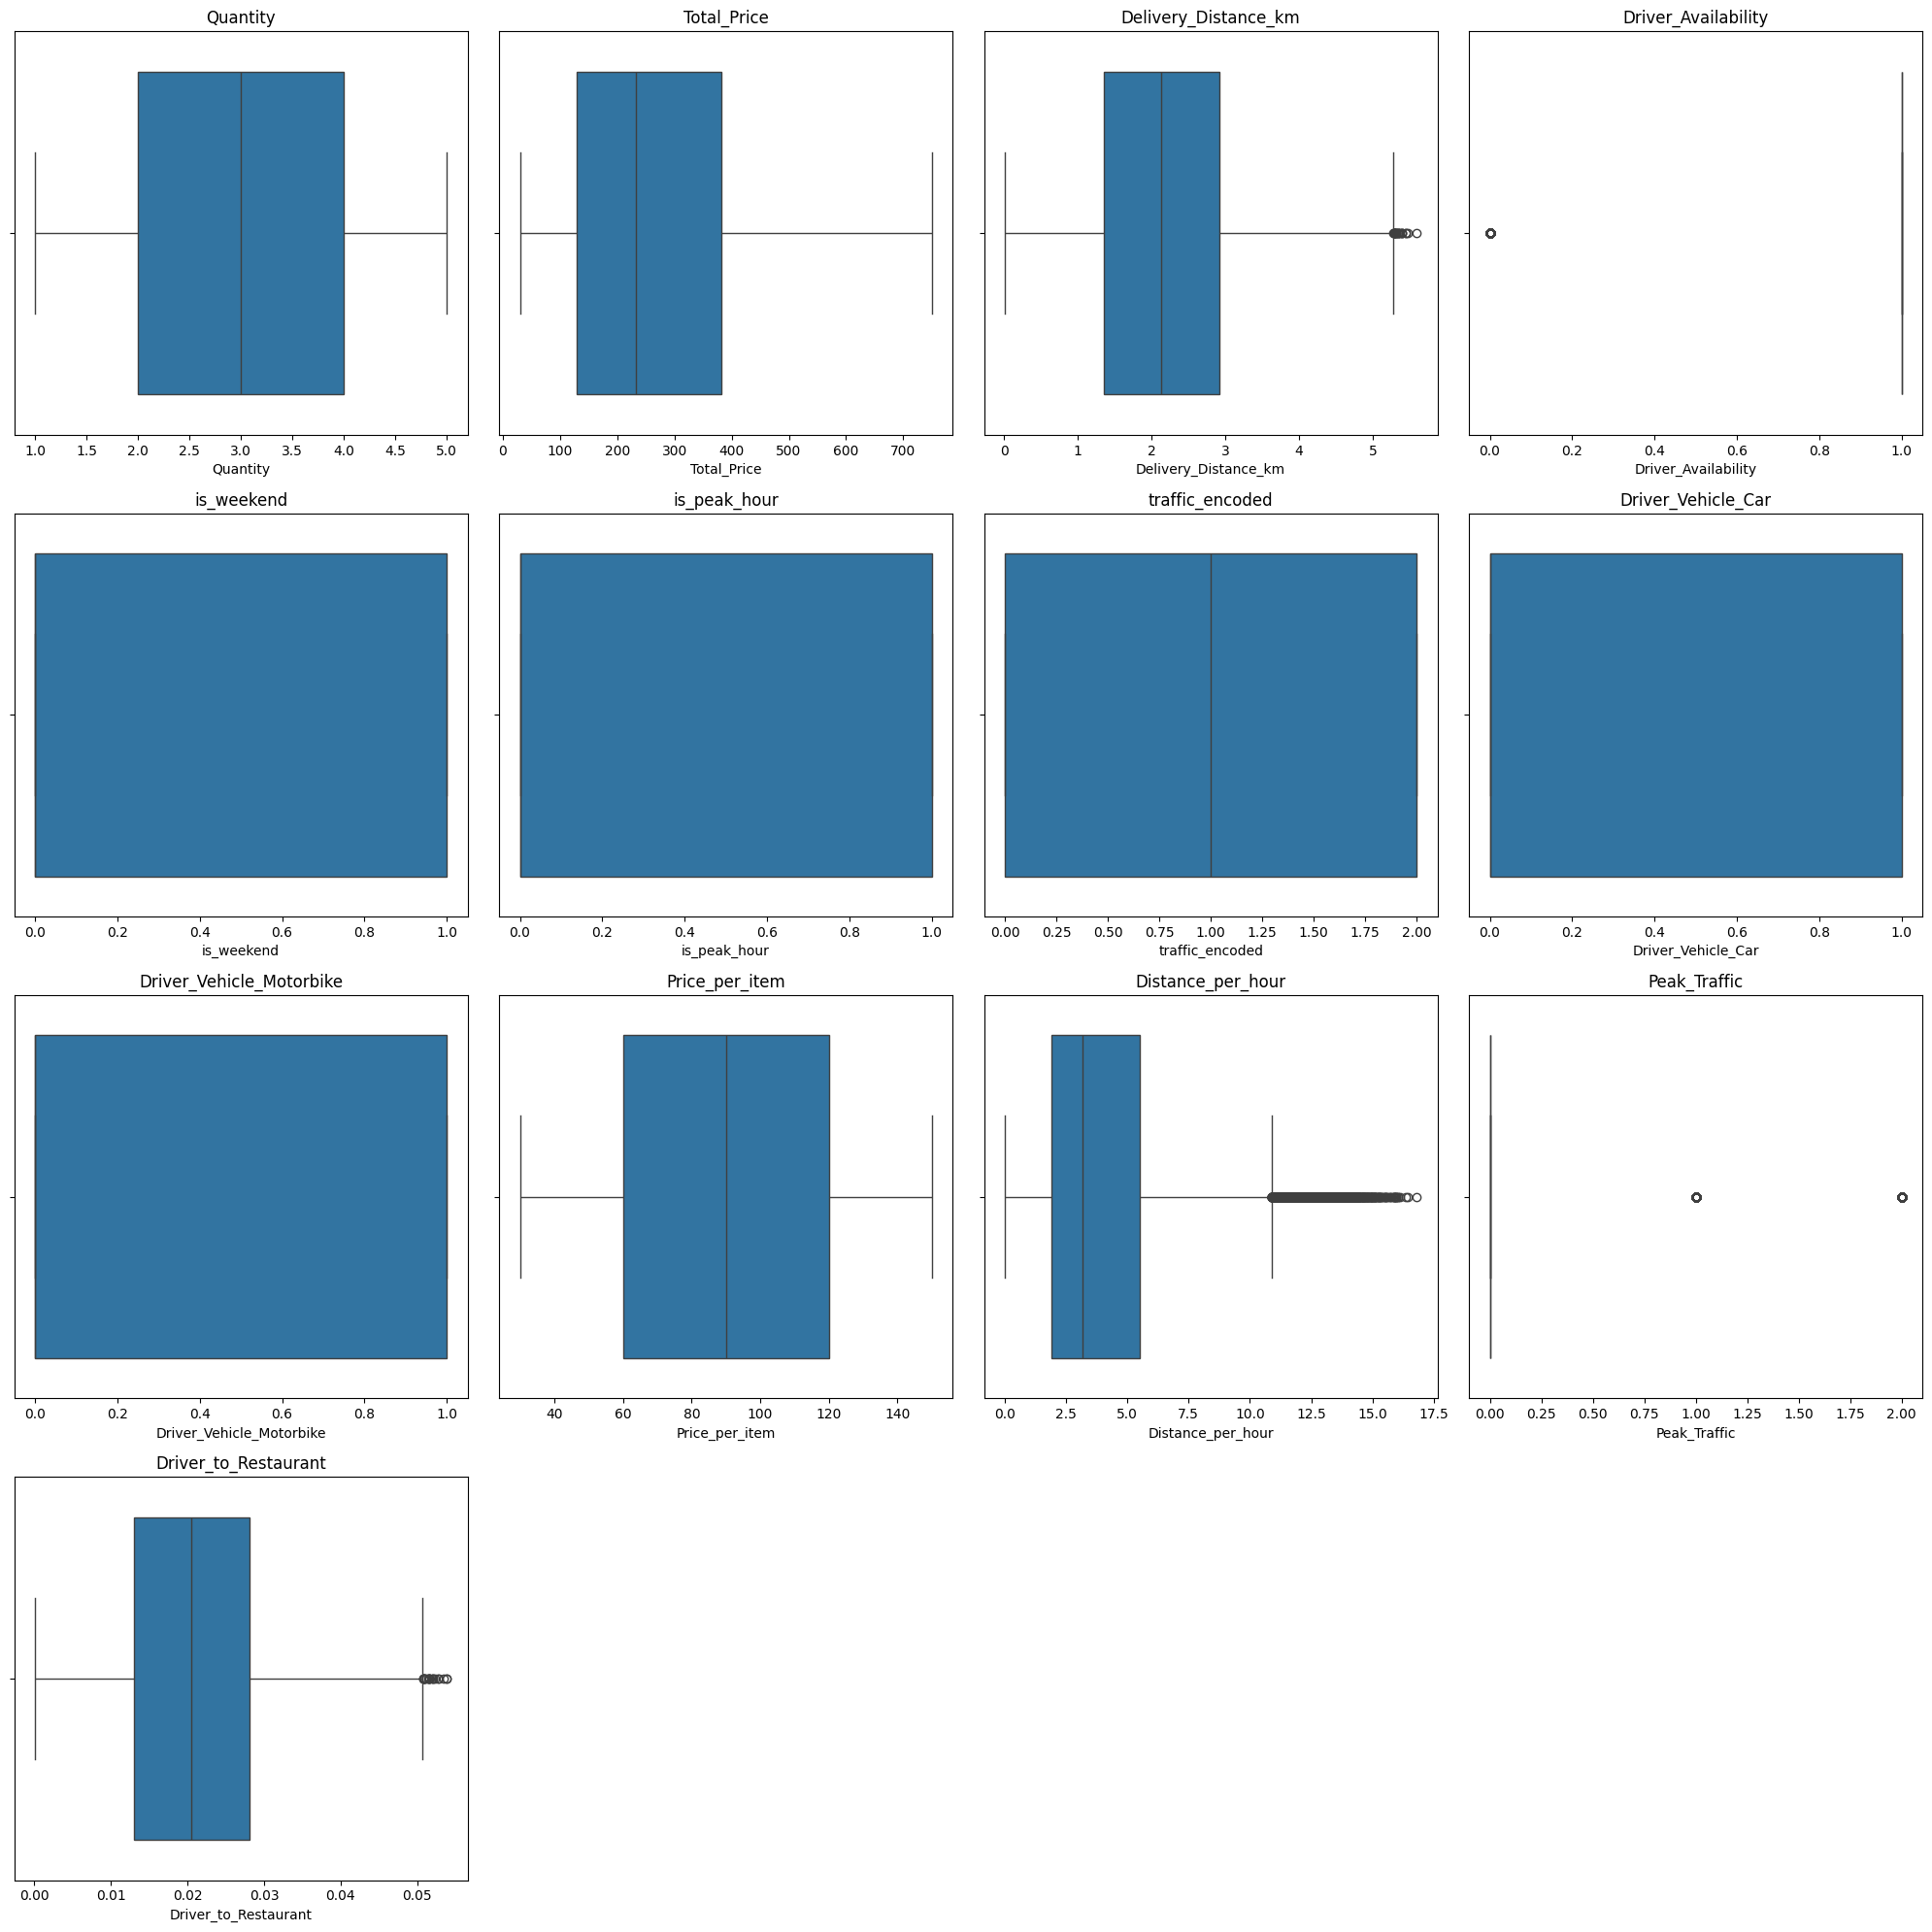

In [90]:
import math
# chọn các cột numeric (bỏ target)
numeric_cols = df8.drop('Delivery_Duration_Minutes', axis=1)\
                 .select_dtypes(include=['int64', 'float64']).columns

n_cols = 4  # số cột hiển thị
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df8[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
sns.pairplot(df8)

In [ ]:
df.isnull().mean()*100  # Tỷ lệ giá trị null của từng thuộc tính

Order_ID                     0.0
User_ID                      0.0
Restaurant_ID                0.0
Driver_ID                    0.0
Item_Name                    0.0
Quantity                     0.0
Total_Price                  0.0
Order_Time                   0.0
Delivery_Time                0.0
Delivery_Duration_Minutes    0.0
City                         0.0
Payment_Method               0.0
Order_Status                 0.0
Driver_Vehicle               0.0
Restaurant_Lat               0.0
Restaurant_Lon               0.0
Customer_Lat                 0.0
Customer_Lon                 0.0
Driver_Lat                   0.0
Driver_Lon                   0.0
Delivery_Distance_km         0.0
Traffic_Level                0.0
Driver_Availability          0.0
dtype: float64

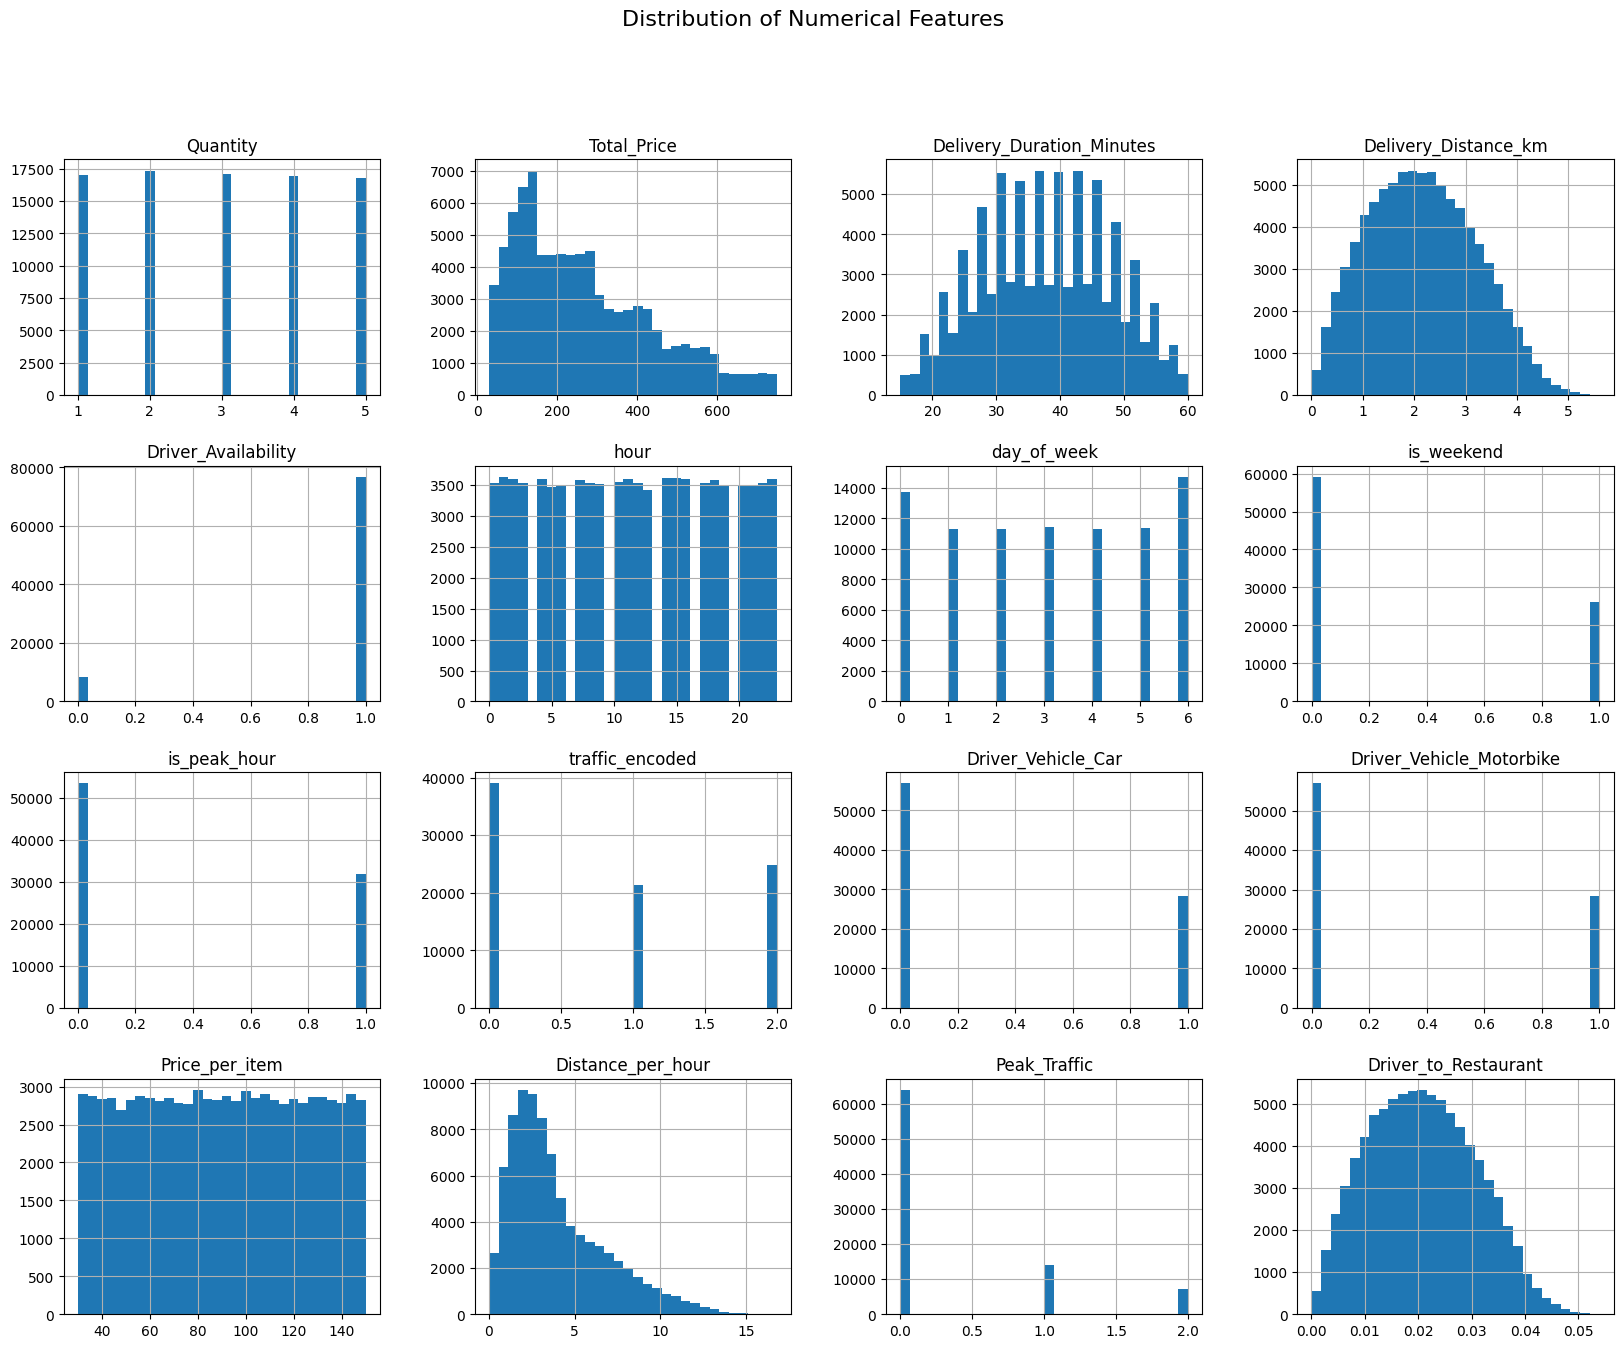

In [ ]:
df8.hist(figsize=(20, 15), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df8.drop('Delivery_Duration_Minutes', axis=1)
y = df8['Delivery_Duration_Minutes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

cv_scores = cross_val_score(
    lr, X_train, y_train,
    cv=5,
    scoring='neg_mean_squared_error'
)

print("CV MSE:", -cv_scores.mean())

CV MSE: 101.70378971482371


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

scores_rf = cross_val_score(
    rf, X_train, y_train,
    cv=5,
    scoring='neg_mean_squared_error'
)

print("RF CV MSE:", -scores_rf.mean())

RF CV MSE: 105.36253303735091


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

scores_dt = cross_val_score(
    dt, X_train, y_train,
    cv=5,
    scoring='neg_mean_squared_error'
)

print("DT CV MSE:", -scores_dt.mean())

DT CV MSE: 210.7361155104028


In [ ]:
from sklearn.pipeline import Pipeline
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

cv_scores_lr = cross_val_score(
    pipeline_lr,
    X_train,
    y_train,
    cv=5,
    scoring='neg_mean_squared_error'
)

print("Linear Regression CV MSE:", -cv_scores_lr.mean())

NameError: name 'StandardScaler' is not defined